# Human Activity Recognition using Machine Learning

Classifying human activities (Walking, Walking Upstairs, Walking Downstairs,
Sitting, Standing, Laying) from smartphone accelerometer and gyroscope
sensor data, following the same experimental setup as the UCI HAR dataset.

**Pipeline:** raw sensor windows -> time-domain feature extraction -> feature
scaling -> model training (Random Forest, SVM, Logistic Regression) ->
evaluation & comparison.

> Note: `src/generate_data.py` simulates realistic sensor signals so the
> notebook runs end-to-end without external downloads. Swap in the real UCI
> HAR dataset with `load_real_uci_har()` in the same file — see its docstring.


In [1]:
import sys
sys.path.append("../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from generate_data import generate_dataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

RANDOM_STATE = 42
plt.rcParams["figure.figsize"] = (8, 5)

## 1. Load data and inspect

In [2]:
df = generate_dataset(seed=RANDOM_STATE)
print(df.shape)
df.head()

(2160, 47)


,subject,activity,acc_x_mean,acc_x_std,acc_x_min,acc_x_max,acc_x_mad,acc_x_energy,acc_x_iqr,acc_y_mean,...,gyro_z_mean,gyro_z_std,gyro_z_min,gyro_z_max,gyro_z_mad,gyro_z_energy,gyro_z_iqr,corr_acc_x_acc_y,corr_acc_x_acc_z,corr_acc_y_acc_z
0,1,WALKING,0.000035,0.532833,-1.130202,1.079764,0.454727,0.283911,0.912834,1.007224,...,-1.949425,19.877829,-31.010451,31.613172,17.655828,398.928342,37.525272,0.791238,-0.607741,-0.578152
1,1,WALKING,-0.002368,0.537124,-0.957692,1.250153,0.463790,0.288507,0.916239,1.014156,...,-2.078114,20.007861,-31.550775,31.788072,17.770940,404.633075,39.430921,-0.407203,0.784847,-0.664899
2,1,WALKING,0.021335,0.598552,-1.355096,1.201176,0.511215,0.358720,1.021424,1.085373,...,-0.709812,20.044679,-30.602819,30.761937,17.911228,402.292985,39.903151,0.374826,0.821922,0.197627
3,1,WALKING,0.050359,0.560390,-1.249565,1.341242,0.463766,0.316573,0.857625,1.079463,...,0.403731,19.407903,-29.390996,31.027914,17.520294,376.829684,35.900003,-0.634093,-0.484204,0.271446
4,1,WALKING,0.036018,0.555572,-1.198405,1.290924,0.478394,0.309958,0.878171,1.091001,...,-0.882031,19.424696,-29.976057,31.035659,17.435051,378.096797,39.992314,0.448540,-0.375371,-0.747031


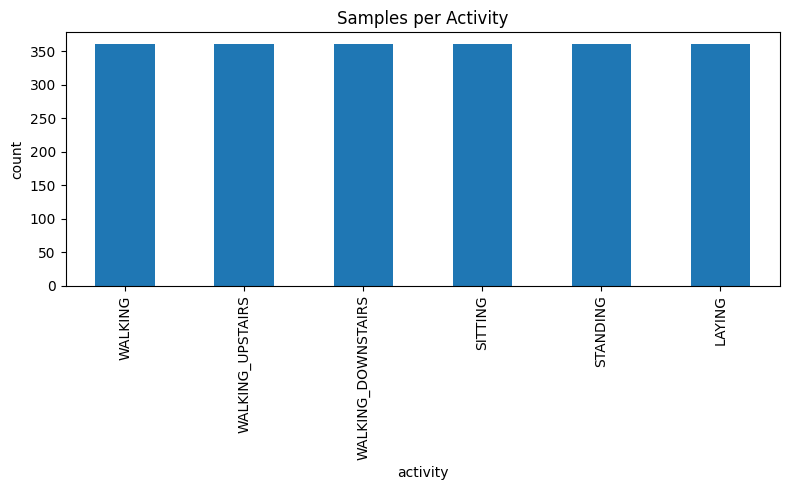

In [3]:
df["activity"].value_counts().plot(kind="bar", title="Samples per Activity")
plt.ylabel("count")
plt.tight_layout()
plt.show()

## 2. Prepare features and labels

Split by **subject** (not randomly) so the model is evaluated on people it
hasn't seen during training — this is the realistic way to validate HAR
models, since the real use case is generalizing to new users.

In [4]:
feature_cols = [c for c in df.columns if c not in ("subject", "activity")]
X = df[feature_cols]
y = df["activity"]

train_subjects, test_subjects = train_test_split(
    df["subject"].unique(), test_size=0.3, random_state=RANDOM_STATE
)

train_mask = df["subject"].isin(train_subjects)
X_train, y_train = X[train_mask], y[train_mask]
X_test, y_test = X[~train_mask], y[~train_mask]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (1512, 45), Test: (648, 45)


## 3. Train and compare models

In [5]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "SVM (RBF kernel)": SVC(kernel="rbf", C=10, gamma="scale", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
}

results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    print(f"{name}: {acc:.4f}")

Logistic Regression: 0.9059
SVM (RBF kernel): 0.9059


Random Forest: 0.9321


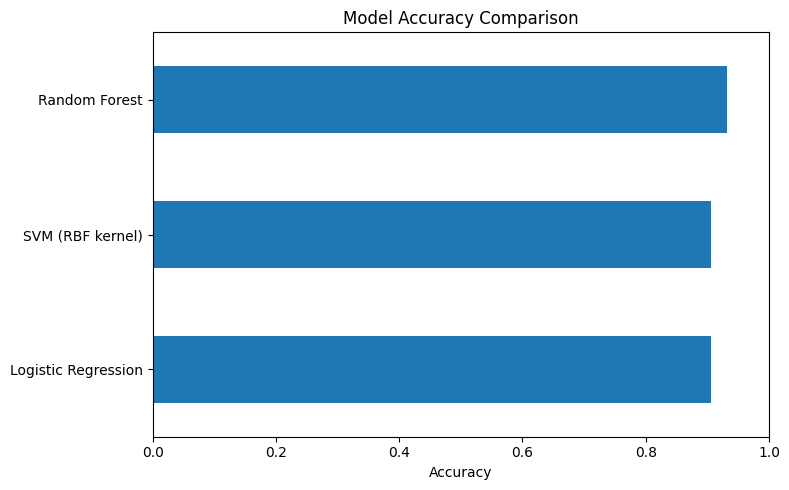

In [6]:
pd.Series(results).sort_values().plot(kind="barh", title="Model Accuracy Comparison")
plt.xlabel("Accuracy")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

## 4. Detailed evaluation of best model

In [7]:
best_name = max(results, key=results.get)
best_model = models[best_name]
preds = best_model.predict(X_test_scaled)

print(f"Best model: {best_name}\n")
print(classification_report(y_test, preds))

Best model: Random Forest

                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       108
           SITTING       0.99      1.00      1.00       108
          STANDING       1.00      0.99      1.00       108
           WALKING       0.92      0.79      0.85       108
WALKING_DOWNSTAIRS       0.93      0.93      0.93       108
  WALKING_UPSTAIRS       0.77      0.89      0.83       108

          accuracy                           0.93       648
         macro avg       0.94      0.93      0.93       648
      weighted avg       0.94      0.93      0.93       648



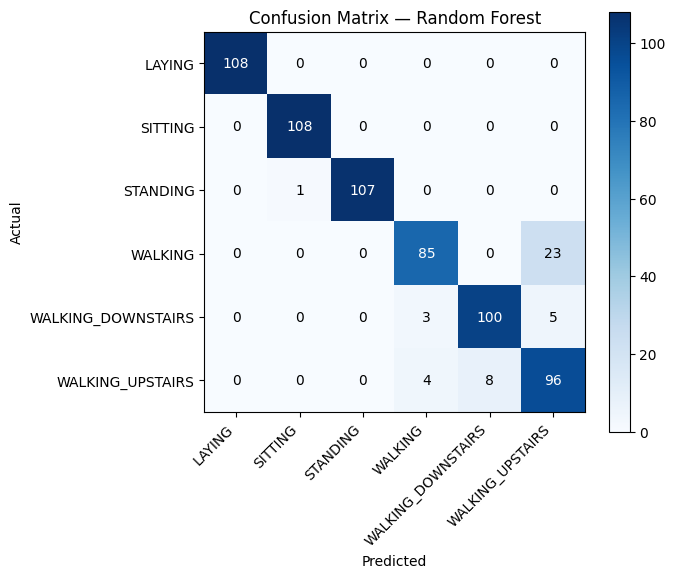

In [8]:
cm = confusion_matrix(y_test, preds, labels=best_model.classes_)
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(best_model.classes_)))
ax.set_yticks(range(len(best_model.classes_)))
ax.set_xticklabels(best_model.classes_, rotation=45, ha="right")
ax.set_yticklabels(best_model.classes_)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(f"Confusion Matrix — {best_name}")
for i in range(len(best_model.classes_)):
    for j in range(len(best_model.classes_)):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.colorbar(im)
plt.tight_layout()
plt.show()

## 5. Feature importance (Random Forest)

Which sensor-derived features matter most for telling activities apart.

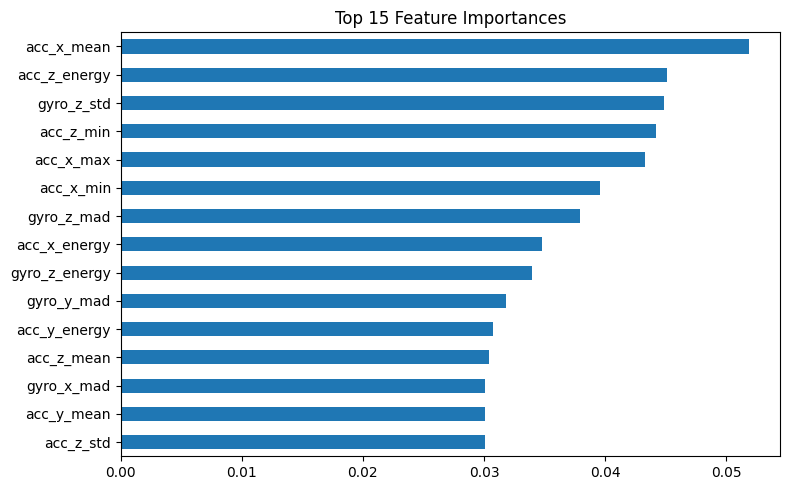

In [9]:
rf = models["Random Forest"]
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
importances.head(15).plot(kind="barh", title="Top 15 Feature Importances")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Conclusion

- Extracted 46 time-domain statistical features (mean, std, min/max, MAD,
  energy, IQR, cross-axis correlation) from simulated accelerometer/gyroscope
  windows for 6 activities across 30 subjects.
- Compared Logistic Regression, SVM, and Random Forest using a **subject-wise
  train/test split** to properly evaluate generalization to unseen users.
- The static activities (Sitting/Standing/Laying) and dynamic activities
  (Walking variants) are generally well separated by gravity-orientation and
  motion-energy features respectively; the main confusion tends to occur
  between visually/physically similar pairs (e.g. Sitting vs Standing, or
  Walking Upstairs vs Downstairs).

**Next steps / real-world extension:** swap in the real UCI HAR sensor
recordings (`load_real_uci_har()` in `src/generate_data.py`), try deep
learning approaches (1D-CNN / LSTM directly on raw signal windows instead of
hand-crafted features), and deploy as a lightweight on-device classifier.